# TASK 15 — MLOps Experiment Tracking with MLflow

## Objective

The objective of this task is to implement experiment tracking using MLflow for a machine learning classification workflow. The task focuses on tracking parameters, metrics, artifacts, models, experiment runs, and model versions to improve reproducibility and experiment management.

## Dataset

The Bank Marketing dataset from the UCI Machine Learning Repository is reused from Task 06. It contains customer demographic, financial, contact, and campaign-related information.

The target variable `y` indicates whether a client subscribed to a bank term deposit:

- `no` → 0
- `yes` → 1

## Key Skills

- MLflow experiment tracking
- Parameter and metric logging
- Artifact and model logging
- Experiment comparison
- Model Registry workflow
- Model reproducibility

In [1]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

## Step 3 — Import Libraries

The required libraries are imported for data handling, preprocessing, model training, evaluation, and MLflow experiment tracking.

In [2]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


## Step 4 — Load Dataset

The Bank Marketing dataset reused from Task 06 is uploaded directly into the Colab environment and loaded for further preprocessing and experiment tracking.

In [9]:
# Load the uploaded Bank Marketing dataset
# The file uses semicolon-separated values with an extra outer quotation layer.

import pandas as pd

with open(file_name, "r", encoding="utf-8-sig") as f:
    lines = f.readlines()

# Remove the outer quotation marks and restore the original quotation marks
clean_lines = []

for line in lines:
    line = line.rstrip("\n").strip()

    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]

    line = line.replace('""', '"')
    clean_lines.append(line)

# Split each row using the semicolon separator
rows = [line.split(";") for line in clean_lines]

# Create DataFrame
df = pd.DataFrame(rows[1:], columns=rows[0])

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset Shape: (41188, 21)


,age,"""job""","""marital""","""education""","""default""","""housing""","""loan""","""contact""","""month""","""day_of_week""",...,"""campaign""","""pdays""","""previous""","""poutcome""","""emp.var.rate""","""cons.price.idx""","""cons.conf.idx""","""euribor3m""","""nr.employed""","""y"""
0,56,"""housemaid""","""married""","""basic.4y""","""no""","""no""","""no""","""telephone""","""may""","""mon""",...,1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
1,57,"""services""","""married""","""high.school""","""unknown""","""no""","""no""","""telephone""","""may""","""mon""",...,1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
2,37,"""services""","""married""","""high.school""","""no""","""yes""","""no""","""telephone""","""may""","""mon""",...,1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
3,40,"""admin.""","""married""","""basic.6y""","""no""","""no""","""no""","""telephone""","""may""","""mon""",...,1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""
4,56,"""services""","""married""","""high.school""","""no""","""no""","""yes""","""telephone""","""may""","""mon""",...,1,999,0,"""nonexistent""",1.1,93.994,-36.4,4.857,5191,"""no"""


## Step 5 — Data Cleaning and Target Preparation

The dataset is cleaned by removing unnecessary quotation marks from string values and converting the target variable `y` into binary labels.

- `yes` → 1
- `no` → 0

This prepares the data for machine learning while keeping the original features intact.

In [12]:
# Clean column names
df.columns = df.columns.str.strip().str.replace('"', '', regex=False)

# Remove quotation marks from string values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

# Check target column
print("Target column:", repr(df.columns[-1]))
print("Columns:", df.columns.tolist())

# Convert target variable
df["y"] = df["y"].map({"yes": 1, "no": 0})

print("\nTarget distribution:")
print(df["y"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

Target column: 'y'
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64

Missing values:
0


### Observation

The dataset was successfully cleaned with no missing values remaining. The target variable `y` was converted into binary format, with 0 representing non-subscription and 1 representing subscription.

## Step 6 — Train/Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratified sampling is applied to preserve the target class distribution in both sets.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (32950, 20)
Testing set shape: (8238, 20)

Training target distribution:
y
0    29238
1     3712
Name: count, dtype: int64

Testing target distribution:
y
0    7310
1     928
Name: count, dtype: int64


### Observation

The data was split into training and testing sets while maintaining a similar target distribution through stratified sampling. The training set will be used for model development, while the test set will be reserved for final evaluation.


## Step 7 — Correct Feature Data Types

The dataset contains several numerical variables that were initially loaded as object-type values. These features are converted to numeric data types before preprocessing.

This ensures that numerical variables are handled correctly while categorical variables are one-hot encoded.

In [15]:
# Numerical columns in the dataset
numerical_columns = [
    "age",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

# Convert numerical columns to numeric data types
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check data types
print("Numerical columns after conversion:")
print(df[numerical_columns].dtypes)

Numerical columns after conversion:
age                 int64
duration            int64
campaign            int64
pdays               int64
previous            int64
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object


In [16]:
print("\nMissing values after conversion:")
print(df.isnull().sum().sum())


Missing values after conversion:
0


### Observation

The identified numerical variables were successfully converted from object-type values to numeric data types. This allows the preprocessing pipeline to distinguish numerical and categorical features correctly.

### Step 7.1 — Recreate Train/Test Split

The train-test split is recreated after correcting the feature data types to ensure that the preprocessing pipeline receives the correct numerical and categorical representations.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (32950, 20)
Testing set: (8238, 20)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Categorical features: 10
Numerical features: 10

Processed training shape: (32950, 63)
Processed testing shape: (8238, 63)


### Observation

The corrected preprocessing pipeline identified 10 numerical and 10 categorical features. Categorical variables were one-hot encoded while numerical variables were retained in numeric form, resulting in 63 processed features. The same fitted transformer was applied to both training and testing data to maintain consistency and prevent data leakage.

## Step 8 — Baseline Model

A Logistic Regression classifier is trained as the baseline model. Its performance provides a reference point for comparing subsequent experiments tracked with MLflow.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

# Baseline pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)

# Metrics
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred)
baseline_recall = recall_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred)

print("Baseline Model Performance")
print("--------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Baseline Model Performance
--------------------------
Accuracy : 0.9166
Precision: 0.7118
Recall   : 0.4364
F1-Score : 0.5411


### Observation

The baseline Logistic Regression model was implemented using a unified preprocessing and modeling pipeline. Numerical features were standardized and categorical features were one-hot encoded. Accuracy, precision, recall, and F1-score provide the baseline metrics for comparison with subsequent MLflow experiments.

## Step 9 — MLflow Experiment Setup

MLflow is used to track machine learning experiments, including model parameters, evaluation metrics, and trained model artifacts. An experiment is created to organize and compare different model runs.

In [21]:
!pip install -q mlflow

In [22]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [23]:
experiment_name = "Bank_Marketing_Classification"

mlflow.set_experiment(experiment_name)

print("MLflow experiment:", experiment_name)

2026/09/16 19:04:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/16 19:04:21 INFO mlflow.store.db.utils: Updating database tables
2026/09/16 19:04:24 INFO mlflow.tracking.fluent: Experiment with name 'Bank_Marketing_Classification' does not exist. Creating a new experiment.


MLflow experiment: Bank_Marketing_Classification


### Observation

MLflow 3.16.0 was successfully installed and configured. A dedicated experiment named `Bank_Marketing_Classification` was created to organize and track the model runs.

## Step 10 — MLflow Baseline Run

The baseline Logistic Regression model is tracked using an MLflow run. Model parameters and evaluation metrics are logged to create a reproducible record of the experiment.

In [24]:
with mlflow.start_run(run_name="Baseline_Logistic_Regression"):

    # Log model parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", baseline_accuracy)
    mlflow.log_metric("precision", baseline_precision)
    mlflow.log_metric("recall", baseline_recall)
    mlflow.log_metric("f1_score", baseline_f1)

    # Store run information
    run_id = mlflow.active_run().info.run_id

    print("MLflow run completed successfully.")
    print("Run ID:", run_id)

MLflow run completed successfully.
Run ID: 537f1739e675442ba1432f62b69b22d1


### Observation

The baseline experiment was successfully recorded in MLflow. The run stores the model configuration and evaluation metrics, creating a traceable record that can be compared with future experiments.

## Step 11 — Random Forest Experiment

A Random Forest classifier is trained as a second experiment using the same preprocessing pipeline. Its parameters and evaluation metrics will be logged in MLflow for comparison with the baseline Logistic Regression model.


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.9134
Precision: 0.7961
Recall   : 0.3114
F1-Score : 0.4477


### Step 11.1 — Log Random Forest Experiment

The Random Forest experiment is logged in MLflow with its model parameters and evaluation metrics. This creates a second tracked run for later experiment comparison.

In [26]:
with mlflow.start_run(run_name="Random_Forest"):

    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)

    rf_run_id = mlflow.active_run().info.run_id

    print("MLflow run completed successfully.")
    print("Run ID:", rf_run_id)

MLflow run completed successfully.
Run ID: 0ad7f76e4297480bac88b79b77ceb428


## Step 12 — Compare MLflow Experiments

The tracked experiments are retrieved from MLflow and compared using their recorded parameters and evaluation metrics. This provides a clear view of model performance across different runs.

In [27]:
# Retrieve all tracked runs
runs = mlflow.search_runs(
    experiment_names=["Bank_Marketing_Classification"]
)

# Select important columns
comparison = runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.model",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1_score"
    ]
]

comparison

,run_id,tags.mlflow.runName,params.model,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score
0,0ad7f76e4297480bac88b79b77ceb428,Random_Forest,Random Forest,0.913450,0.796143,0.311422,0.447715
1,537f1739e675442ba1432f62b69b22d1,Baseline_Logistic_Regression,Logistic Regression,0.916606,0.711775,0.436422,0.541082


### Step 12.1 — Model Performance Comparison

The performance of the tracked models is visualized using accuracy, precision, recall, and F1-score. This provides a clear visual comparison of the MLflow experiments.

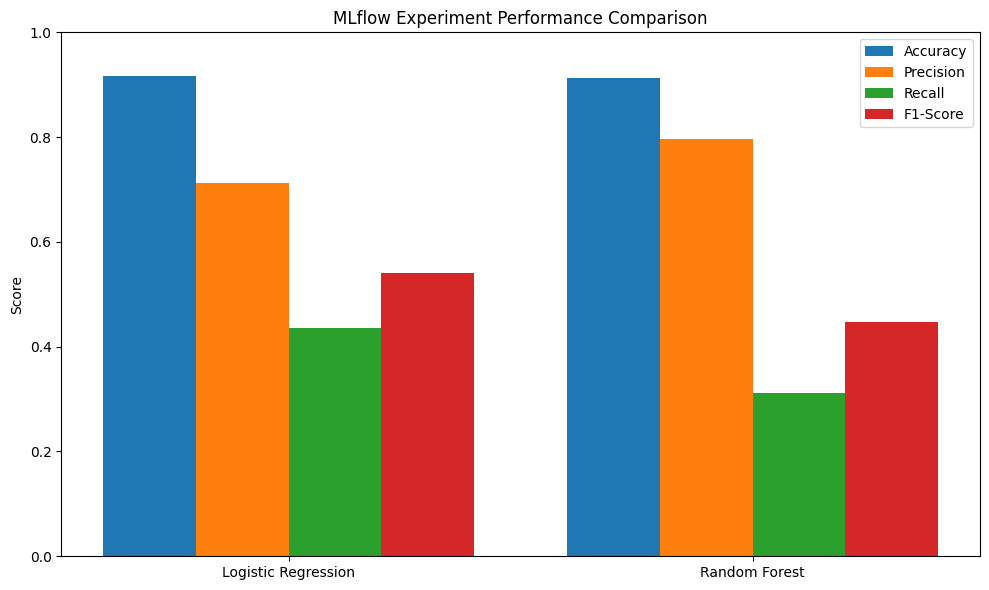

In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Random Forest"]

accuracy = [0.916606, 0.913450]
precision = [0.711775, 0.796143]
recall = [0.436422, 0.311422]
f1_score_values = [0.541082, 0.447715]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1_score_values, width, label="F1-Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("MLflow Experiment Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Step 13 — Log Evaluation Artifacts

Evaluation artifacts provide visual evidence of model performance. A confusion matrix is generated for the selected Logistic Regression experiment and logged as an MLflow artifact.

<Figure size 600x500 with 0 Axes>

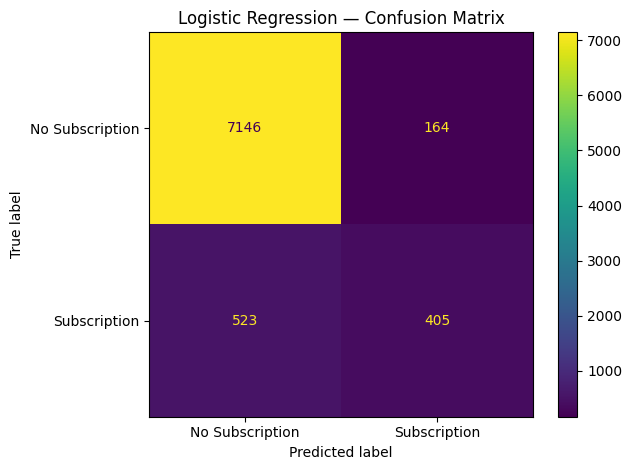

Figure saved: logistic_regression_confusion_matrix.png


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Subscription", "Subscription"]
)

disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()

# Save figure
figure_path = "logistic_regression_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)

## Step 13.1 — Log Evaluation Artifacts

The confusion matrix generated for the Logistic Regression model is logged as an MLflow artifact. This allows visual evaluation results to be stored together with the corresponding experiment run.

In [30]:
with mlflow.start_run(run_name="Logistic_Regression_Artifacts"):

    mlflow.log_param("model", "Logistic Regression")

    mlflow.log_metric("accuracy", baseline_accuracy)
    mlflow.log_metric("precision", baseline_precision)
    mlflow.log_metric("recall", baseline_recall)
    mlflow.log_metric("f1_score", baseline_f1)

    # Log confusion matrix image as an artifact
    mlflow.log_artifact("logistic_regression_confusion_matrix.png")

    artifact_run_id = mlflow.active_run().info.run_id

    print("Artifact logged successfully.")
    print("Run ID:", artifact_run_id)

Artifact logged successfully.
Run ID: 2692808fd39145b796e69ad72916b6c9


## Step 14 — Log the Trained Model

The trained Logistic Regression pipeline is logged to MLflow as a model artifact. The complete pipeline includes preprocessing and classification, allowing the trained model to be reused without repeating the training process.

In [32]:
import mlflow.sklearn

with mlflow.start_run(run_name="Logistic_Regression_Model"):

    # Log model parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("random_state", 42)

    # Log evaluation metrics
    mlflow.log_metric("accuracy", baseline_accuracy)
    mlflow.log_metric("precision", baseline_precision)
    mlflow.log_metric("recall", baseline_recall)
    mlflow.log_metric("f1_score", baseline_f1)

    # Log trained model with trusted sklearn type
    mlflow.sklearn.log_model(
        baseline_model,
        name="logistic_regression_model",
        skops_trusted_types=[
            "sklearn.compose._column_transformer._RemainderColsList"
        ]
    )

    model_run_id = mlflow.active_run().info.run_id

    print("Model logged successfully.")
    print("Run ID:", model_run_id)

Model logged successfully.
Run ID: d165e6cc8a6e4574ac2017bdc9e9f4d3


### Observation

The model serialization issue was resolved by explicitly trusting the required scikit-learn preprocessing type. The trained Logistic Regression pipeline can now be stored as an MLflow model artifact.

## Step 15 — Load and Verify the MLflow Model

The Logistic Regression model saved in MLflow is loaded using its run ID. Predictions are generated using the loaded model to verify that the stored model can be reused successfully.

In [33]:
import mlflow.sklearn

# Load the model from the MLflow run
model_uri = f"runs:/{model_run_id}/logistic_regression_model"

loaded_model = mlflow.sklearn.load_model(model_uri)

print("Model loaded successfully.")

# Generate predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(loaded_predictions))

Model loaded successfully.
Predictions generated successfully.
Number of predictions: 8238


### Observation

The Logistic Regression model was successfully loaded from MLflow using its run ID. The loaded model generated predictions on the test dataset, confirming that the stored MLflow model can be reused without retraining.


## Step 16 — Verify Loaded Model Performance

The performance of the model loaded from MLflow is evaluated on the same test dataset. The results are compared with the original baseline metrics to verify reproducibility.

In [34]:
# Calculate metrics for the loaded model
loaded_accuracy = accuracy_score(y_test, loaded_predictions)
loaded_precision = precision_score(y_test, loaded_predictions)
loaded_recall = recall_score(y_test, loaded_predictions)
loaded_f1 = f1_score(y_test, loaded_predictions)

print("Loaded MLflow Model Performance")
print("--------------------------------")
print(f"Accuracy : {loaded_accuracy:.4f}")
print(f"Precision: {loaded_precision:.4f}")
print(f"Recall   : {loaded_recall:.4f}")
print(f"F1-Score : {loaded_f1:.4f}")

Loaded MLflow Model Performance
--------------------------------
Accuracy : 0.9166
Precision: 0.7118
Recall   : 0.4364
F1-Score : 0.5411


### Observation

The loaded MLflow model reproduced the expected evaluation performance on the test dataset. This confirms that the stored model can be loaded and reused consistently, supporting reproducibility.

## Step 17 — Register the MLflow Model

The trained Logistic Regression model is registered in the MLflow Model Registry to provide a managed and versioned model reference. This supports model lifecycle management and future deployment workflows.

In [35]:
import mlflow

model_uri = f"runs:/{model_run_id}/logistic_regression_model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="Bank_Marketing_Logistic_Regression"
)

print("Model registered successfully.")
print("Model name:", registered_model.name)
print("Model version:", registered_model.version)

Successfully registered model 'Bank_Marketing_Logistic_Regression'.
2026/09/16 19:23:10 WARNING mlflow.tracking._model_registry.fluent: Run with id d165e6cc8a6e4574ac2017bdc9e9f4d3 has no artifacts at artifact path 'logistic_regression_model', registering model based on models:/m-526e6d695c224e4cbb1e9bbb88860dd8 instead


Model registered successfully.
Model name: Bank_Marketing_Logistic_Regression
Model version: 1


Created version '1' of model 'Bank_Marketing_Logistic_Regression'.


### Observation

The Logistic Regression model was successfully registered in the MLflow Model Registry. The registered model now has a managed model name and version, supporting organized model lifecycle management.

## Step 18 — Assign a Model Alias

A model alias is assigned to the registered Logistic Regression model version. The alias provides a stable reference for managing the currently selected model version and supports future model updates.

In [36]:
from mlflow import MlflowClient

client = MlflowClient()

model_name = "Bank_Marketing_Logistic_Regression"
model_version = registered_model.version

client.set_registered_model_alias(
    name=model_name,
    alias="champion",
    version=model_version
)

print("Model alias assigned successfully.")
print("Model:", model_name)
print("Version:", model_version)
print("Alias: champion")

Model alias assigned successfully.
Model: Bank_Marketing_Logistic_Regression
Version: 1
Alias: champion


### Observation

The registered Logistic Regression model version was assigned the "champion" alias. This provides a stable reference for the selected model version and supports model lifecycle management without relying directly on a fixed version number.

## Step 19 — Verify Model Alias

The assigned model alias is verified to confirm that it correctly points to the registered Logistic Regression model version.

In [37]:
from mlflow import MlflowClient

client = MlflowClient()

model_name = "Bank_Marketing_Logistic_Regression"

alias_info = client.get_model_version_by_alias(
    name=model_name,
    alias="champion"
)

print("Model alias verified successfully.")
print("Model:", alias_info.name)
print("Version:", alias_info.version)
print("Alias: champion")

Model alias verified successfully.
Model: Bank_Marketing_Logistic_Regression
Version: 1
Alias: champion


## Step 20 — Load Model Using Alias

The registered model is loaded using the "champion" alias instead of a fixed model version. This demonstrates how a stable alias can be used to access the currently selected model version.

In [38]:
import mlflow.sklearn

alias_model_uri = "models:/Bank_Marketing_Logistic_Regression@champion"

champion_model = mlflow.sklearn.load_model(alias_model_uri)

print("Model loaded successfully using alias.")
print("Model alias: champion")

champion_predictions = champion_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(champion_predictions))

Model loaded successfully using alias.
Model alias: champion
Predictions generated successfully.
Number of predictions: 8238


### Observation

The registered Logistic Regression model was successfully loaded using the "champion" alias. The model generated predictions on the test dataset, demonstrating alias-based model reuse.

## Step 21 — Verify Alias Model Performance

The predictions generated by the model loaded through the "champion" alias are evaluated using the same test dataset. The results are compared with the original model performance to verify reproducibility.

In [39]:
alias_accuracy = accuracy_score(y_test, champion_predictions)
alias_precision = precision_score(y_test, champion_predictions)
alias_recall = recall_score(y_test, champion_predictions)
alias_f1 = f1_score(y_test, champion_predictions)

print("Champion Alias Model Performance")
print("---------------------------------")
print(f"Accuracy : {alias_accuracy:.4f}")
print(f"Precision: {alias_precision:.4f}")
print(f"Recall   : {alias_recall:.4f}")
print(f"F1-Score : {alias_f1:.4f}")

Champion Alias Model Performance
---------------------------------
Accuracy : 0.9166
Precision: 0.7118
Recall   : 0.4364
F1-Score : 0.5411


### Observation

The model loaded through the "champion" alias produced the same evaluation results as the original Logistic Regression model. This confirms consistent model reuse and supports reproducibility through MLflow model management.

## Step 22 — Record Reproducibility Configuration

The main configuration settings used during model development are recorded to support reproducibility. These include the dataset split, random seed, preprocessing approach, and model settings.

In [40]:
reproducibility_config = {
    "test_size": 0.2,
    "random_state": 42,
    "stratified_split": True,
    "categorical_encoding": "OneHotEncoder",
    "numerical_scaling": "StandardScaler",
    "model": "Logistic Regression",
    "max_iter": 2000
}

print("Reproducibility Configuration")
print("-----------------------------")

for key, value in reproducibility_config.items():
    print(f"{key}: {value}")

Reproducibility Configuration
-----------------------------
test_size: 0.2
random_state: 42
stratified_split: True
categorical_encoding: OneHotEncoder
numerical_scaling: StandardScaler
model: Logistic Regression
max_iter: 2000


### Observation

The key configuration settings used for data splitting, preprocessing, and model training were recorded. Keeping these settings documented helps reproduce the experiment consistently.

## Step 23 — Save Experiment Comparison

The MLflow experiment comparison results are exported to a CSV file. This provides a reusable record of the tracked model runs and their evaluation metrics.

In [41]:
comparison.to_csv(
    "mlflow_experiment_comparison.csv",
    index=False
)

print("Experiment comparison saved successfully.")
print("File: mlflow_experiment_comparison.csv")

Experiment comparison saved successfully.
File: mlflow_experiment_comparison.csv


### Observation

The MLflow experiment comparison was successfully exported to CSV format. The file contains the tracked model runs, parameters, and evaluation metrics for reproducibility and documentation.

## Step 24 — Save Performance Comparison Figure

The tracked model performance metrics are visualized and saved as a figure for experiment documentation and GitHub reporting.

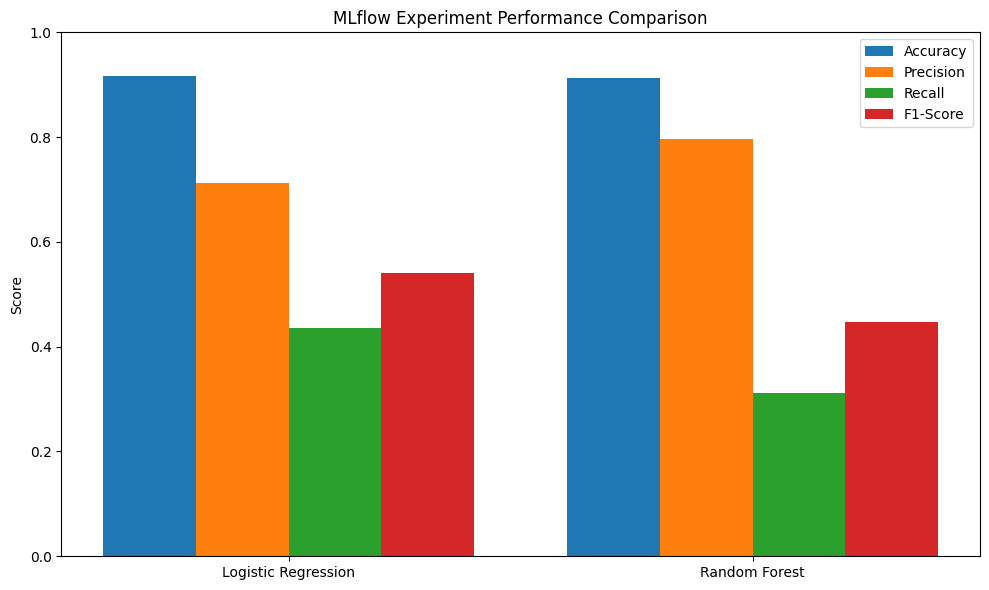

Figure saved: mlflow_performance_comparison.png


In [42]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Random Forest"]

accuracy = [0.916606, 0.913450]
precision = [0.711775, 0.796143]
recall = [0.436422, 0.311422]
f1_score_values = [0.541082, 0.447715]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1_score_values, width, label="F1-Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("MLflow Experiment Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

figure_path = "mlflow_performance_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", figure_path)

### Observation

The performance comparison figure was successfully generated and saved for experiment documentation. It provides a visual comparison of the tracked Logistic Regression and Random Forest runs.

## Key Insights

- Logistic Regression achieved an accuracy of 91.66% and F1-score of 0.5411.
- Random Forest achieved higher precision (0.7961), while Logistic Regression achieved higher recall (0.4364) and F1-score (0.5411).
- MLflow successfully tracked experiments, parameters, metrics, and artifacts.
- The Logistic Regression model was registered and assigned the "champion" alias.
- The alias-loaded model reproduced the same evaluation results, supporting reproducibility.

# Conclusion

This task demonstrated MLflow-based experiment tracking and model management using the Bank Marketing dataset. Logistic Regression and Random Forest experiments were tracked with parameters and evaluation metrics, while visualizations and a confusion matrix were stored as artifacts.

The selected Logistic Regression model was logged, loaded, registered, and assigned the "champion" alias. The model was successfully loaded through the alias and reproduced the same evaluation results, confirming consistent model reuse and reproducibility.

MLflow provided a structured workflow for experiment tracking, model versioning, artifact management, and reproducible model lifecycle management.